In [2]:
import numpy as np
import scipy.stats
import scipy.special
import matplotlib.pyplot as plt
import random
import yaml
SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/lgssm/"

In [5]:
# Import samples 
experiment_ID = 0
posterior_samples_dict_path = results_path + f"kalman_filter/posterior_samples{experiment_ID}.npz"
posterior_samples_dict_config_path = results_path + f"kalman_filter/posterior_samples{experiment_ID}.yaml"

posterior_samples_dict = np.load(posterior_samples_dict_path)
rho_samples = posterior_samples_dict["rho_samples"]
tau_samples = posterior_samples_dict["tau_samples"]
z_samples = posterior_samples_dict["z_samples"]

with open(posterior_samples_dict_config_path, "r") as f:
    posterior_samples_dict_config = yaml.safe_load(f)

x_observed_ID = posterior_samples_dict_config["x_observed_ID"]
total_time = posterior_samples_dict_config["total_time"]
rho_lower = posterior_samples_dict_config["rho_lower"]
rho_upper = posterior_samples_dict_config["rho_upper"]
T = posterior_samples_dict_config["T"]
num_iterations = posterior_samples_dict_config["num_iterations"]
step_sizes = posterior_samples_dict_config["step_sizes"]
rho_0 = posterior_samples_dict_config["rho_0"]
tau_0 = posterior_samples_dict_config["tau_0"]
sigma_true = posterior_samples_dict_config["sigma_true"]
tau_loc = posterior_samples_dict_config["tau_loc"]
tau_scale = posterior_samples_dict_config["tau_scale"]
tau_lower = posterior_samples_dict_config["tau_lower"]
tau_upper = posterior_samples_dict_config["tau_upper"]
rejection_rate = posterior_samples_dict_config["rejection_rate"]


In [6]:
# Import trajectory 
trajectory_ID = x_observed_ID
trajectory_path = results_path + f"data/trajectory{trajectory_ID}.npz"
trajectory_config_path = results_path + f"data/trajectory{trajectory_ID}.yaml"

trajectory = np.load(trajectory_path)
x = trajectory["x"][:T+1]
z = trajectory["z"][:T+1]

with open(trajectory_config_path, "r") as f:
    trajectory_config = yaml.safe_load(f)
rho_true = trajectory_config["rho_true"]
sigma_true = trajectory_config["sigma_true"]
tau_true = trajectory_config["tau_true"]
trajectory_config

{'length': 5000, 'rho_true': 0.8, 'sigma_true': 0.5, 'tau_true': 1.0}

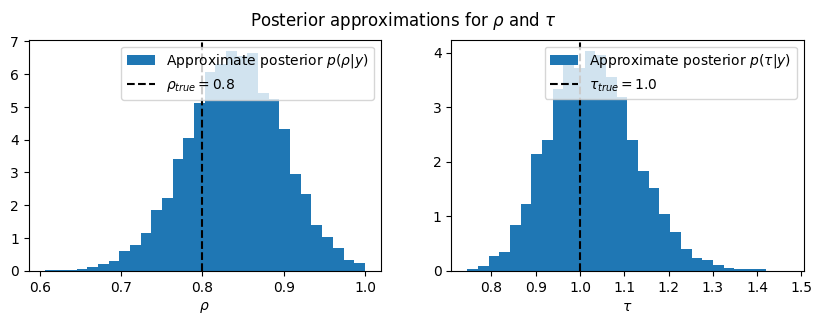

In [7]:
fig, ax = plt.subplots(figsize=(10,3), ncols=2)

bins=30
ax[0].hist(rho_samples, bins=bins, density=True, label=r"Approximate posterior $p(\rho | y)$")
ax[0].axvline(rho_true, linestyle="--", label=r"$\rho_{true} = $" + str(rho_true), color="k")
ax[0].set_xlabel(r"$\rho$")
ax[0].legend()

ax[1].hist(tau_samples, bins=bins, density=True, label=r"Approximate posterior $p(\tau | y)$")
ax[1].axvline(tau_true, linestyle="--", label=r"$\tau_{true} = $" + str(tau_true), color="k")
ax[1].set_xlabel(r"$\tau$")
ax[1].legend()

plt.suptitle(r"Posterior approximations for $\rho$ and $\tau$")

plt.show()

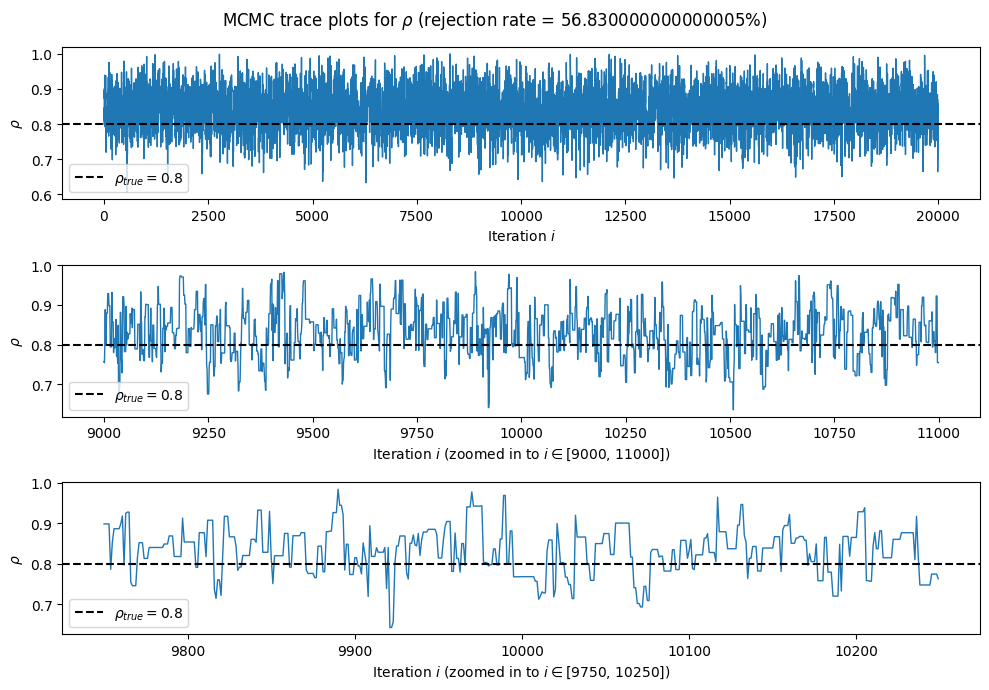

In [9]:
fig, ax = plt.subplots(figsize=(10,7), nrows=3)

linewidth = 1
time_range = range(0, num_iterations)
ax[0].plot(time_range, rho_samples, linewidth=linewidth)
ax[0].axhline(rho_true, linestyle="--", label=r"$\rho_{true} = $" + str(rho_true), color="k")
ax[0].set_xlabel(r"Iteration $i$")
ax[0].set_ylabel(r"$\rho$")
ax[0].legend()

n_min, n_max = 9000, 11000
ax[1].plot(time_range[n_min:n_max], rho_samples[n_min:n_max], linewidth=linewidth)
ax[1].axhline(rho_true, linestyle="--", label=r"$\rho_{true} = $" + str(rho_true), color="k")
ax[1].set_xlabel(r"Iteration $i$ (zoomed in to $i \in$" +f"[{n_min}, {n_max}])")
ax[1].set_ylabel(r"$\rho$")
ax[1].legend()

n_min_, n_max_ = 9750, 10250
ax[2].plot(time_range[n_min_:n_max_], rho_samples[n_min_:n_max_], linewidth=linewidth)
ax[2].axhline(rho_true, linestyle="--", label=r"$\rho_{true} = $" + str(rho_true), color="k")
ax[2].set_xlabel(r"Iteration $i$ (zoomed in to $i \in$" +f"[{n_min_}, {n_max_}])")
ax[2].set_ylabel(r"$\rho$")
ax[2].legend()

plt.suptitle(r"MCMC trace plots for $\rho$" + f" (rejection rate = {100*rejection_rate}%)")

plt.tight_layout()
plt.show()

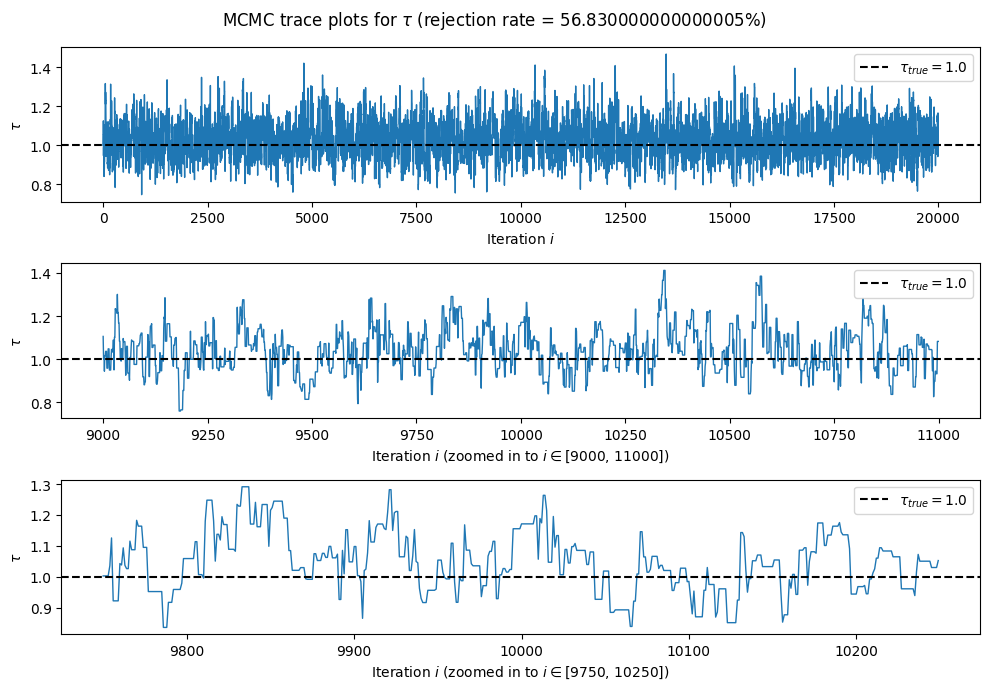

In [10]:
fig, ax = plt.subplots(figsize=(10,7), nrows=3)

linewidth = 1
time_range = range(0, num_iterations)
ax[0].plot(time_range, tau_samples, linewidth=linewidth)
ax[0].axhline(tau_true, linestyle="--", label=r"$\tau_{true} = $" + str(tau_true), color="k")
ax[0].set_xlabel(r"Iteration $i$")
ax[0].set_ylabel(r"$\tau$")
ax[0].legend()

n_min, n_max = 9000, 11000
ax[1].plot(time_range[n_min:n_max], tau_samples[n_min:n_max], linewidth=linewidth)
ax[1].axhline(tau_true, linestyle="--", label=r"$\tau_{true} = $" + str(tau_true), color="k")
ax[1].set_xlabel(r"Iteration $i$ (zoomed in to $i \in$" +f"[{n_min}, {n_max}])")
ax[1].set_ylabel(r"$\tau$")
ax[1].legend()

n_min_, n_max_ = 9750, 10250
ax[2].plot(time_range[n_min_:n_max_], tau_samples[n_min_:n_max_], linewidth=linewidth)
ax[2].axhline(tau_true, linestyle="--", label=r"$\tau_{true} = $" + str(tau_true), color="k")
ax[2].set_xlabel(r"Iteration $i$ (zoomed in to $i \in$" +f"[{n_min_}, {n_max_}])")
ax[2].set_ylabel(r"$\tau$")
ax[2].legend()

plt.suptitle(r"MCMC trace plots for $\tau$"+ f" (rejection rate = {100*rejection_rate}%)")

plt.tight_layout()
plt.show()

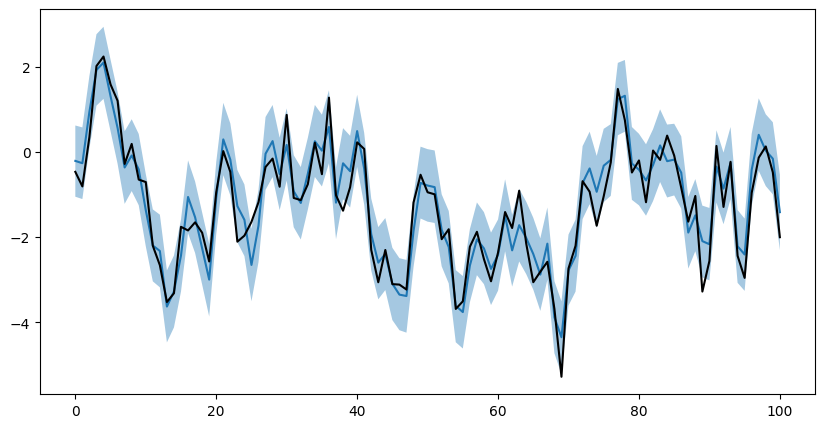

In [24]:
lq = np.quantile(z_samples, 0.025, axis=0)
uq = np.quantile(z_samples, 0.975, axis=0)
mean = np.mean(z_samples, axis=0)
fig, ax = plt.subplots(figsize=(10,5))
time_range = range(T+1)
ax.fill_between(time_range, lq, uq, alpha=0.4)
ax.plot(mean)
ax.plot(z, color="k")